In [2]:
!pip list

Package               Version
--------------------- --------------
appdirs               1.4.4
attrs                 23.2.0
Babel                 2.10.3
bcc                   0.29.1
bcrypt                3.2.2
beautifulsoup4        4.12.3
blinker               1.7.0
Brlapi                0.8.5
Brotli                1.1.0
certifi               2023.11.17
chardet               5.2.0
click                 8.1.6
cloud-init            24.4.1
colorama              0.4.6
command-not-found     0.3
configobj             5.0.8
contourpy             1.0.7
cryptography          41.0.7
cssselect             1.2.0
cupshelpers           1.0
cycler                0.11.0
dbus-python           1.3.2
decorator             5.1.1
defer                 1.0.6
Deprecated            1.2.14
distro                1.9.0
distro-info           1.7+build1
duplicity             2.1.4
fasteners             0.18
fonttools             4.46.0
fs                    2.4.16
html5lib              1.1
httplib2              0.

In [3]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install opencv-python matplotlib gdown 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
#pip install tensorflow==2.12


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
  pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:

import os
import numpy as np
import cv2
import tensorflow as tf

from typing import List
from matplotlib import pyplot as plt
import imageio

2025-04-04 07:47:40.371669: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-04 07:47:42.419177: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-04 07:47:42.420682: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-04 07:47:50.066157: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/psd/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  wa

In [11]:
#pip install numpy<2 --force-reinstall


/bin/bash: line 1: 2: No such file or directory


Note: you may need to restart the kernel to use updated packages.


In [8]:

print(tf.config.list_physical_devices('CPU'))


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [9]:
import tensorflow as tf

Pillow version: 11.1.0


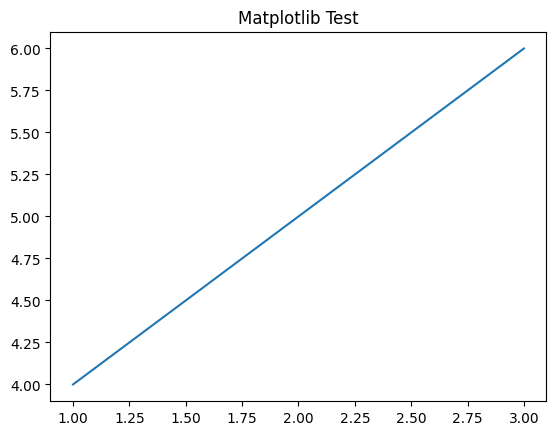

In [10]:
import PIL
import matplotlib.pyplot as plt

print("Pillow version:", PIL.__version__)

# Test Matplotlib
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Matplotlib Test")
plt.show()


In [15]:
# %load_ext autoreload
# %autoreload 2

In [11]:
import PIL
print(PIL.__version__)


11.1.0


In [12]:
import tensorflow as tf

# List available GPUs
physical_devices = tf.config.list_physical_devices('GPU')

if physical_devices:  # Check if GPU is available
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("GPU memory growth enabled")
    except Exception as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("No GPU found. Running on CPU.")


No GPU found. Running on CPU.


In [13]:
def load_video(path:str) -> List[float]: 

    cap = cv2.VideoCapture(path)
    frames = []
    for _ in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))): 
        ret, frame = cap.read()
        frame = tf.image.rgb_to_grayscale(frame)
        frames.append(frame[190:236,80:220,:])
    cap.release()
    
    mean = tf.math.reduce_mean(frames)
    std = tf.math.reduce_std(tf.cast(frames, tf.float32))
    return tf.cast((frames - mean), tf.float32) / std

In [14]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]

In [15]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="")
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size ={char_to_num.vocabulary_size()})"
)

The vocabulary is: ['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', "'", '?', '!', '1', '2', '3', '4', '5', '6', '7', '8', '9', ' '] (size =40)


In [16]:
char_to_num.get_vocabulary()

['',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 "'",
 '?',
 '!',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ' ']

In [17]:
char_to_num(['n','i','c','k'])

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([14,  9,  3, 11])>

In [18]:
print(tf.__version__)

2.12.0


In [19]:
num_to_char([14,  9,  3, 11])

<tf.Tensor: shape=(4,), dtype=string, numpy=array([b'n', b'i', b'c', b'k'], dtype=object)>

In [20]:
def load_alignments(path:str) -> List[str]: 
    with open(path, 'r') as f: 
        lines = f.readlines() 
    tokens = []
    for line in lines:
        line = line.split()
        if line[2] != 'sil': 
            tokens = [*tokens,' ',line[2]]
    return char_to_num(tf.reshape(tf.strings.unicode_split(tokens, input_encoding='UTF-8'), (-1)))[1:]

In [21]:
def load_data(path: str): 
    path = bytes.decode(path.numpy())
    #file_name = path.split('/')[-1].split('.')[0]
    # File name splitting for windows
    file_name = path.split('\\')[-1].split('.')[0]
    video_path = os.path.join('data','s1',f'{file_name}.mpg')
    alignment_path = os.path.join('data','alignments','s1',f'{file_name}.align')
    frames = load_video(video_path) 
    alignments = load_alignments(alignment_path)
    
    return frames, alignments

In [22]:
import os
import tensorflow as tf

def load_data(path: tf.Tensor):
    """Loads video frames and alignments from a given path."""
    
    # Ensure path is a string (if it's a TensorFlow tensor)
    if isinstance(path, tf.Tensor):
        path = path.numpy().decode('utf-8')
    
    # Extract the file name (cross-platform)
    file_name = os.path.splitext(os.path.basename(path))[0]

    # Construct paths
    video_path = os.path.join('data', 's1', f'{file_name}.mpg')
    alignment_path = os.path.join('data', 'alignments', 's1', f'{file_name}.align')

    # Check if files exist before loading
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")
    if not os.path.exists(alignment_path):
        raise FileNotFoundError(f"Alignment file not found: {alignment_path}")

    # Load video and alignment data
    frames = load_video(video_path)
    alignments = load_alignments(alignment_path)

    return frames, alignments


In [23]:
import os
import tensorflow as tf

test_path = './data/s1/bbal6n.mpg'  # Use Linux-style path
file_name = os.path.splitext(os.path.basename(test_path))[0]  # Extract file name without extension
print(file_name)  # Output: bbal6n


bbal6n


In [24]:
test_path = './data/s1/bbal6n.mpg'  # Use forward slashes


In [25]:
tf.convert_to_tensor(test_path).numpy().decode('utf-8').split('\\')[-1].split('.')[0]

''

In [26]:
frames, alignments = load_data(tf.convert_to_tensor(test_path))

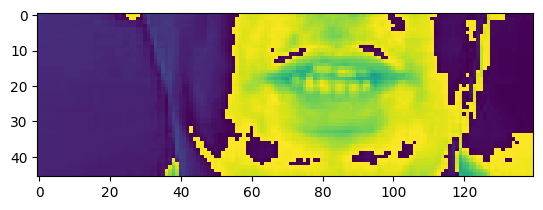

In [27]:
plt.imshow(frames[40])

In [28]:
alignments

<tf.Tensor: shape=(21,), dtype=int64, numpy=
array([ 2,  9, 14, 39,  2, 12, 21,  5, 39,  1, 20, 39, 12, 39, 19,  9, 24,
       39, 14, 15, 23])>

In [29]:
tf.strings.reduce_join([bytes.decode(x) for x in num_to_char(alignments.numpy()).numpy()])

<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue at l six now'>

In [30]:
def mappable_function(path:str) ->List[str]:
    result = tf.py_function(load_data, [path], (tf.float32, tf.int64))
    return result

In [31]:
from matplotlib import pyplot as plt

In [32]:
data = tf.data.Dataset.list_files('./data/s1/*.mpg')
data = data.shuffle(500, reshuffle_each_iteration=False)
data = data.map(mappable_function)
data = data.padded_batch(2, padded_shapes=([75,None,None,None],[40]))
data = data.prefetch(tf.data.AUTOTUNE)
# Added for split 
train = data.take(450)
test = data.skip(450)

In [33]:
print('./data/s1/*.mpg')

./data/s1/*.mpg


In [34]:
len(test)

50

In [35]:
import os

alignment_path = "./data/alignments/s1/"
print("Checking file:", os.path.abspath(alignment_path))

if not os.path.exists(alignment_path):
    print("Error: File does not exist!")
else:
    print("File found, proceeding...")


Checking file: /home/psd/Documents/pritesh_study_material/Pritesh_BE/sem_8/TULIP/data/alignments/s1
File found, proceeding...


In [36]:
print(data)  # Check dataset type


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 75, None, None, None), dtype=tf.float32, name=None), TensorSpec(shape=(None, 40), dtype=tf.int64, name=None))>


In [37]:
for sample in data.take(1):  # Get the first sample
    print(sample)



2025-04-04 07:50:28.813826: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1000]
	 [[{{node Placeholder/_0}}]]
2025-04-04 07:50:28.814577: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1000]
	 [[{{node Placeholder/_0}}]]


(<tf.Tensor: shape=(2, 75, 46, 140, 1), dtype=float32, numpy=
array([[[[[ 1.4030454 ],
          [ 1.5138121 ],
          [ 1.5507344 ],
          ...,
          [ 0.29537797],
          [ 0.36922246],
          [ 0.36922246]],

         [[ 1.4768898 ],
          [ 1.5138121 ],
          [ 1.5507344 ],
          ...,
          [ 0.29537797],
          [ 0.36922246],
          [ 0.36922246]],

         [[ 1.5507344 ],
          [ 1.5507344 ],
          [ 1.4768898 ],
          ...,
          [ 0.4061447 ],
          [ 0.33230022],
          [ 0.33230022]],

         ...,

         [[ 1.0707451 ],
          [ 1.0338229 ],
          [ 1.0338229 ],
          ...,
          [ 0.11076674],
          [ 0.11076674],
          [ 0.11076674]],

         [[ 1.0338229 ],
          [ 1.0338229 ],
          [ 1.0338229 ],
          ...,
          [ 0.11076674],
          [ 0.11076674],
          [ 0.11076674]],

         [[ 1.0338229 ],
          [ 1.0338229 ],
          [ 1.0338229 ],
          ...

In [38]:
frames, alignments = data.as_numpy_iterator().next()

2025-04-04 07:50:34.353979: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1000]
	 [[{{node Placeholder/_0}}]]
2025-04-04 07:50:34.355219: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1000]
	 [[{{node Placeholder/_0}}]]


In [39]:
len(frames)

2

In [40]:
sample = data.as_numpy_iterator()

In [41]:
val = sample.next(); val[0]

array([[[[[0.5783168 ],
          [0.8867525 ],
          [1.1951882 ],
          ...,
          [0.30843565],
          [0.2698812 ],
          [0.2698812 ]],

         [[0.30843565],
          [0.5783168 ],
          [0.8867525 ],
          ...,
          [0.30843565],
          [0.2698812 ],
          [0.2698812 ]],

         [[1.4265149 ],
          [1.272297  ],
          [0.9253069 ],
          ...,
          [0.30843565],
          [0.2698812 ],
          [0.2698812 ]],

         ...,

         [[1.1951882 ],
          [1.1566336 ],
          [1.1566336 ],
          ...,
          [0.03855446],
          [0.03855446],
          [0.03855446]],

         [[1.1566336 ],
          [1.1566336 ],
          [1.1566336 ],
          ...,
          [0.        ],
          [0.        ],
          [0.        ]],

         [[1.1566336 ],
          [1.1566336 ],
          [1.1566336 ],
          ...,
          [0.        ],
          [0.        ],
          [0.        ]]],


        [[[0.6168

In [42]:
imageio.mimsave('./animation.gif', val[0][0], fps=10)

Lossy conversion from float32 to uint8. Range [0.0, 9.831385612487793]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.831385612487793]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.831385612487793]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.831385612487793]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.831385612487793]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.831385612487793]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. Range [0.0, 9.831385612487793]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from float32 to uint8. R

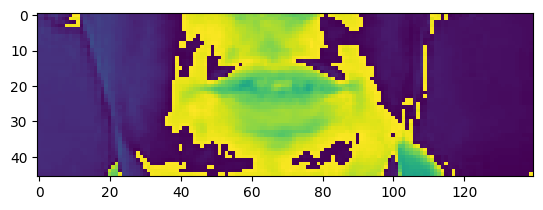

In [43]:
# 0:videos, 0: 1st video out of the batch,  0: return the first frame in the video 
plt.imshow(val[0][0][35])

In [44]:
tf.strings.reduce_join([num_to_char(word) for word in val[1][0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'set red in t nine soon'>

In [45]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten, Lambda, MultiHeadAttention
from tensorflow.keras.optimizers import Adam,legacy
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler

In [46]:
data.as_numpy_iterator().next()[0][0].shape

(75, 46, 140, 1)

In [47]:
model = Sequential()
model.add(Conv3D(128, 3, input_shape=(75,46,140,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(Conv3D(256, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(Conv3D(75, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

model.add(TimeDistributed(Flatten()))
#model.add(TimeDistributed(Reshape((75, 5 * 17))))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True))) 
model.add(Dropout(.5))

model.add(Dense(char_to_num.vocabulary_size()+1, kernel_initializer='he_normal', activation='softmax'))

2025-04-04 07:51:05.647659: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-04 07:51:05.649947: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-04 07:51:05.651522: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [70]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPool3D, Flatten, Dense, Dropout, TimeDistributed, LSTM, Reshape, Activation, Bidirectional

def build_model(char_to_num):
    model = Sequential()

    model.add(Conv3D(128, 3, input_shape=(75, 46, 140, 1), padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPool3D((1, 2, 2)))

    model.add(Conv3D(256, 3, padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPool3D((1, 2, 2)))

    model.add(Conv3D(75, 3, padding='same'))
    model.add(Activation('relu'))
    model.add(MaxPool3D((1, 2, 2)))

    model.add(TimeDistributed(Flatten()))
    # Optional: model.add(TimeDistributed(Reshape((75, 5 * 17))))

    model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
    model.add(Dropout(0.5))

    model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True))) 
    model.add(Dropout(0.5))

    model.add(Dense(char_to_num.vocabulary_size() + 1, kernel_initializer='he_normal', activation='softmax'))

    return model


In [71]:
model = build_model(char_to_num)

from tensorflow.keras.optimizers.legacy import Adam
model.compile(optimizer=Adam(), loss='categorical_crossentropy')

model.load_weights('./models/checkpoint')


2025-04-04 08:09:51.221239: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-04 08:09:51.223507: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-04 08:09:51.224864: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [48]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv3d (Conv3D)             (None, 75, 46, 140, 128)  3584      
                                                                 
 activation (Activation)     (None, 75, 46, 140, 128)  0         
                                                                 
 max_pooling3d (MaxPooling3D  (None, 75, 23, 70, 128)  0         
 )                                                               
                                                                 
 conv3d_1 (Conv3D)           (None, 75, 23, 70, 256)   884992    
                                                                 
 activation_1 (Activation)   (None, 75, 23, 70, 256)   0         
                                                                 
 max_pooling3d_1 (MaxPooling  (None, 75, 11, 35, 256)  0         
 3D)                                                    

In [49]:
yhat = model.predict(val[0])

2025-04-04 07:51:13.863107: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-04 07:51:13.865894: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-04 07:51:13.867362: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 6s 6s/step


In [50]:
tf.strings.reduce_join([num_to_char(x) for x in tf.argmax(yhat[0],axis=1)])

<tf.Tensor: shape=(), dtype=string, numpy=b'iiiii9999999999999999999999999999999999999999999999999999999999999999999999'>

In [51]:
tf.strings.reduce_join([num_to_char(tf.argmax(x)) for x in yhat[0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'iiiii9999999999999999999999999999999999999999999999999999999999999999999999'>

In [52]:
model.input_shape

(None, 75, 46, 140, 1)

In [53]:
model.output_shape

(None, 75, 41)

In [54]:
def scheduler(epoch, lr):
    if epoch < 30:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [55]:
def CTCLoss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [56]:
class ProduceExample(tf.keras.callbacks.Callback): 
    def __init__(self, dataset) -> None: 
        self.dataset = dataset.as_numpy_iterator()
    
    def on_epoch_end(self, epoch, logs=None) -> None:
        data = self.dataset.next()
        yhat = self.model.predict(data[0])
        decoded = tf.keras.backend.ctc_decode(yhat, [75,75], greedy=False)[0][0].numpy()
        for x in range(len(yhat)):           
            print('Original:', tf.strings.reduce_join(num_to_char(data[1][x])).numpy().decode('utf-8'))
            print('Prediction:', tf.strings.reduce_join(num_to_char(decoded[x])).numpy().decode('utf-8'))
            print('~'*100)

In [57]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer, loss=CTCLoss)

In [58]:
checkpoint_callback = ModelCheckpoint(
    os.path.join('models', 'checkpoints', 'model.h5'), 
    monitor='loss', 
    save_weights_only=False
)

In [59]:
schedule_callback = LearningRateScheduler(scheduler)

In [60]:
example_callback = ProduceExample(test)

2025-04-04 07:51:56.313325: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1000]
	 [[{{node Placeholder/_0}}]]
2025-04-04 07:51:56.314995: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1000]
	 [[{{node Placeholder/_0}}]]


In [66]:
#model.fit(train, validation_data=test, epochs=90, callbacks=[checkpoint_callback, schedule_callback, example_callback])

In [61]:
import tensorflow as tf

# Check if GPU is available
gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    print("GPU is available!")
    for gpu in gpus:
        print(f"GPU: {gpu}")
else:
    print("No GPU found. Using CPU.")

No GPU found. Using CPU.


In [62]:
from tensorflow.python.client import device_lib

# List all devices
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16454515528336543306
xla_global_id: -1
]


In [63]:
import tensorflow as tf

# Check if GPU is used by performing a simple operation
with tf.device('/GPU:0'):
    if gpus:
     print("GPU is available!")
    for gpu in gpus:
        print(f"GPU: {gpu}")
    else:
     print("No GPU found. Using CPU.")
    a = tf.random.normal([10000, 10000])
    b = tf.random.normal([10000, 10000])
    c = tf.matmul(a, b)
    print(c)

No GPU found. Using CPU.


2025-04-04 07:52:09.048308: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 400000000 exceeds 10% of free system memory.


tf.Tensor(
[[ -11.435711   -76.39061    -16.454979  ...   25.94334    231.0579
   -90.346344 ]
 [  33.90622     47.27823    104.542076  ...  -18.439283    12.613369
    89.033806 ]
 [ -51.42281    -30.666403    -1.5423179 ... -114.04416      5.625241
   -47.557007 ]
 ...
 [   6.1521673  -20.627966    20.24823   ...  -63.14293     83.36354
   358.42603  ]
 [ 168.20728     92.21373     99.656235  ... -161.51318    -38.42783
   -55.505802 ]
 [-205.21648     -9.789341   -55.245056  ...  153.2461      92.41865
    34.38197  ]], shape=(10000, 10000), dtype=float32)


In [64]:
pip install gdown


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [65]:
import gdown

url = 'https://drive.google.com/uc?id=1vWscXs4Vt0a_1IH1-ct2TCgXAZT-N3_Y'
output = 'checkpoints.zip'

gdown.download(url, output, quiet=False)
gdown.extractall('checkpoints.zip', 'models')


Downloading...
From (original): https://drive.google.com/uc?id=1vWscXs4Vt0a_1IH1-ct2TCgXAZT-N3_Y
From (redirected): https://drive.google.com/uc?id=1vWscXs4Vt0a_1IH1-ct2TCgXAZT-N3_Y&confirm=t&uuid=da071aa7-de8f-4988-8b43-a82acad55882
To: /home/psd/Documents/pritesh_study_material/Pritesh_BE/sem_8/TULIP/checkpoints.zip
100%|██████████| 94.5M/94.5M [03:10<00:00, 495kB/s]


['models/checkpoint.index',
 'models/__MACOSX/._checkpoint.index',
 'models/checkpoint.data-00000-of-00001',
 'models/__MACOSX/._checkpoint.data-00000-of-00001',
 'models/checkpoint',
 'models/__MACOSX/._checkpoint']

In [ ]:
# import tensorflow as tf

# # Load the model
# model = tf.keras.models.load_model('./models/checkpoint', compile=False)

# # Use legacy optimizers when compiling
# from tensorflow.keras.optimizers.legacy import Adam

# model.compile(optimizer=Adam(), loss='categorical_crossentropy')


OSError: Unable to synchronously open file (file signature not found)

In [73]:
model = build_model(char_to_num)

from tensorflow.keras.optimizers.legacy import Adam
model.compile(optimizer=Adam(), loss='categorical_crossentropy')

model.load_weights('./models/checkpoint')


2025-04-04 08:10:43.989066: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-04 08:10:43.991539: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-04 08:10:43.994195: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [74]:
from tensorflow.keras.optimizers.legacy import Adam
optimizer = Adam(learning_rate=0.001)


In [75]:
from tensorflow.keras.optimizers.legacy import Adam

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy')
model.save('./models/')


2025-04-04 08:11:04.313445: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-04 08:11:04.315445: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-04 08:11:04.316662: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

INFO:tensorflow:Assets written to: ./models/assets


INFO:tensorflow:Assets written to: ./models/assets


In [76]:
test_data = test.as_numpy_iterator()

In [77]:
sample = test_data.next()

[mpeg1video @ 0x70aac4005e00] ac-tex damaged at 22 17
[mpeg1video @ 0x70aac4005e00] Warning MVs not available


In [78]:
yhat = model.predict(sample[0])

2025-04-04 08:16:40.738923: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-04-04 08:16:40.741977: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-04-04 08:16:40.744293: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 5s 5s/step


In [79]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in sample[1]]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ REAL TEXT


[<tf.Tensor: shape=(), dtype=string, numpy=b'set red by u eight please'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'bin green at t nine soon'>]

In [80]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75,75], greedy=True)[0][0].numpy()

In [81]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS


[<tf.Tensor: shape=(), dtype=string, numpy=b'set red by u eight please'>,
 <tf.Tensor: shape=(), dtype=string, numpy=b'bin green at t nine soon'>]

In [108]:
# sample = load_data(tf.convert_to_tensor('./realvdo/upupPritesh.mpg'))


In [110]:
def load_data(path: tf.Tensor): 
    path = bytes.decode(path.numpy())
    file_name = os.path.splitext(os.path.basename(path))[0]  # safer split
    video_path = path  # use actual path passed to function
    alignment_path = os.path.join('data', 'alignments','s1', f'{file_name}.align')

    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")
    if not os.path.exists(alignment_path):
        raise FileNotFoundError(f"Alignment file not found: {alignment_path}")

    frames = load_video(video_path) 
    alignments = load_alignments(alignment_path)
    
    return frames, alignments


In [119]:
def load_alignments(path):
    with open(path, 'r') as f:
        lines = f.readlines()

    tokens = []
    for line in lines:
        line = line.strip().split()
        if len(line) == 3 and line[2] != 'sil':
            tokens.extend([' ', line[2]])  # Space is treated as token separator

    # Convert characters to numeric values
    return char_to_num(tf.reshape(tf.strings.unicode_split(tokens, input_encoding='UTF-8'), (-1)))[1:]


In [116]:

pip install scikit-image


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.2.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 1.7 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.8/315.8 kB 1.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 1.5 MB/s eta 0:00:0000:0100:01
Using cached numpy-2.2.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.8/226.8 kB 994.1 kB/s eta 0:00:000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
  Attempting uninstall: imageio
    Found existing installation: imageio 2.23.0
    Uninstalling imageio-2.23.0:
      Successfully uninstalled imageio-2.23.0
ERROR: pip's dependency resolver does not currently take into

In [120]:
def load_data(path):
    base = os.path.basename(path.numpy().decode())
    file_name = os.path.splitext(base)[0]

    video_path = f"data/s1/{file_name}.mpg"
    alignment_path = f"data/alignments/s1/{file_name}.align"

    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")
    if not os.path.exists(alignment_path):
        raise FileNotFoundError(f"Alignment file not found: {alignment_path}")

    frames = load_video(video_path) 
    alignments = load_alignments(alignment_path)

    return frames, alignments


In [121]:
from skimage.transform import resize

def load_video(path:str):
    cap = cv2.VideoCapture(path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized = resize(gray, (46,140))  # height x width
        frames.append(resized)
    cap.release()
    
    frames = np.stack(frames, axis=0)
    if frames.shape[0] > 75:
        frames = frames[:75]
    else:
        pad_width = ((0, 75 - frames.shape[0]), (0,0), (0,0))
        frames = np.pad(frames, pad_width, constant_values=0)
    
    return np.expand_dims(frames, axis=-1)


In [123]:
frames, alignments = load_data(tf.convert_to_tensor('./data/s1/upupPritesh.mpg'))
print("Frames shape:", frames.shape)
print("Alignments:", alignments)


Frames shape: (75, 46, 140, 1)
Alignments: tf.Tensor([21 16 39 21 16], shape=(5,), dtype=int64)


In [124]:
print("Frames shape:", frames.shape)
print("Alignments:", alignments)


Frames shape: (75, 46, 140, 1)
Alignments: tf.Tensor([21 16 39 21 16], shape=(5,), dtype=int64)


In [137]:
yhat = model.predict(tf.expand_dims(sample[0], axis=0))  # Add batch dimension


1/1 [==============================] - 2s 2s/step


In [135]:
print("Frames shape:", sample[0].shape)
print("Alignments shape:", sample[1].shape)


Frames shape: (75, 46, 140, 1)
Alignments shape: (5,)


In [138]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[yhat.shape[1]])[0][0]
decoded_text = tf.strings.reduce_join(num_to_char(decoded)).numpy().decode()
print("Predicted text:", decoded_text)


Predicted text: pla red at fue again p e aown


In [131]:
sample = load_data(tf.convert_to_tensor('./data/s1/upupPritesh.mpg'))


In [132]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in [sample[1]]]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ REAL TEXT


[<tf.Tensor: shape=(), dtype=string, numpy=b'up up'>]

In [133]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75], greedy=True)[0][0].numpy()

In [134]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ PREDICTIONS


[<tf.Tensor: shape=(), dtype=string, numpy=b'pla red at fue again p e aown'>]